# Oráculo: calibración polarimétrica (ZDR y ΦDP de sistema)

Oráculo de `docs/algorithms/calibracion-polarimetrica.md`, independiente de
cualquier crate Rust (todavía no existe implementación — primer paso del
método de `docs/algorithms/roadmap.md` §"Método de estudio"). La página es
clara en que **el DSP aplica la corrección, no la determina en línea** — los
procedimientos de campaña (birdbath, inyección de señal) viven del lado del
operador/RCP. Lo que este oráculo valida son las dos mitades que sí tienen
contenido numérico verificable sin hardware: que aplicar un offset conocido
recupera la verdad-terreno, y que el *procedimiento* de estimación (el que
usaría una campaña de birdbath o el arranque de un radial) recupera
correctamente el offset inyectado quando se le da la oportunidad de medirlo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260915)
plt.rcParams["figure.figsize"] = (9, 4)
np.set_printoptions(precision=4, suppress=True)

In [2]:
def gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap=3):
    v_a = wavelength_m / (4.0 * prt_s)
    f_k = np.fft.fftfreq(m, d=prt_s)
    v_k = f_k * wavelength_m / 2.0
    n = np.arange(-wrap, wrap + 1)
    dv = v_k[:, None] - mean_v - n[None, :] * 2.0 * v_a
    acc = np.exp(-0.5 * (dv / sigma_v) ** 2).sum(axis=1)
    return power_s * acc / acc.sum()


def complex_gaussian(rng, variance, size=None):
    sigma = np.sqrt(variance / 2.0)
    return rng.normal(0.0, sigma, size=size) + 1j * rng.normal(0.0, sigma, size=size)


def generate_dual_pol_cell(power_h, mean_v, sigma_v, wavelength_m, prt_s, m, zdr_db, rho_hv, phidp_deg,
                            noise_floor, rng, wrap=3):
    power_v = power_h / 10.0 ** (zdr_db / 10.0)
    spec_h = gaussian_doppler_spectrum(power_h, mean_v, sigma_v, wavelength_m, prt_s, m, wrap)
    spec_v = gaussian_doppler_spectrum(power_v, mean_v, sigma_v, wavelength_m, prt_s, m, wrap)
    rho = rho_hv * np.exp(1j * np.radians(phidp_deg))
    l21, l22 = np.conj(rho), np.sqrt(1.0 - rho_hv ** 2)
    w1 = complex_gaussian(rng, 1.0, size=m)
    w2 = complex_gaussian(rng, 1.0, size=m)
    wh, wv = w1, l21 * w1 + l22 * w2
    yh = np.fft.ifft(wh * np.sqrt(spec_h)) * m
    yv = np.fft.ifft(wv * np.sqrt(spec_v)) * m
    if noise_floor > 0.0:
        yh = yh + complex_gaussian(rng, noise_floor, size=m)
        yv = yv + complex_gaussian(rng, noise_floor, size=m)
    return yh, yv


def periodogram_raw(y):
    m = len(y)
    yf = np.fft.fft(y)
    return (np.abs(yf) ** 2) / (m ** 2)


def hildebrand_sekhon(p, navg=1):
    p_sorted = np.sort(p)
    n = len(p_sorted)
    rtest = 1.0 + 1.0 / navg
    nnoise = n
    sum1 = 0.0
    sum2 = 0.0
    for i in range(n):
        pwr = p_sorted[i]
        npts = i + 1
        sum1 += pwr
        sum2 += pwr * pwr
        if npts * sum2 < sum1 * sum1 * rtest:
            nnoise = npts
        else:
            sum1 -= pwr
            sum2 -= pwr * pwr
            break
    return sum1 / nnoise


def noise_floor_estimate(y):
    return hildebrand_sekhon(periodogram_raw(y)) * len(y)


def measure_zdr(power_h, mean_v, sigma_v, wavelength_m, prt_s, m, zdr_true_scene, rho_hv,
                gain_imbalance_db, noise_floor, rng):
    """zdr_true_scene: ZDR físico del meteoro. gain_imbalance_db: desbalance
    de ganancia H/V del receptor, lo que la calibración tiene que corregir.
    Un desbalance de ganancia se suma directamente al ZDR en dB — así es
    como se modela aquí, no como una cantidad separada con su propia física."""
    zdr_seen_by_receiver = zdr_true_scene + gain_imbalance_db
    yh, yv = generate_dual_pol_cell(power_h, mean_v, sigma_v, wavelength_m, prt_s, m,
                                     zdr_seen_by_receiver, rho_hv, 0.0, noise_floor, rng)
    nh, nv = noise_floor_estimate(yh), noise_floor_estimate(yv)
    ph, pv = max(np.mean(np.abs(yh) ** 2) - nh, 0.0), max(np.mean(np.abs(yv) ** 2) - nv, 0.0)
    if ph <= 0.0 or pv <= 0.0:
        return np.nan
    return 10.0 * np.log10(ph / pv)


def measure_phidp(power_h, mean_v, sigma_v, wavelength_m, prt_s, m, rho_hv, phidp_true_deg, noise_floor, rng):
    yh, yv = generate_dual_pol_cell(power_h, mean_v, sigma_v, wavelength_m, prt_s, m, 1.0,
                                     rho_hv, phidp_true_deg, noise_floor, rng)
    rhv = np.mean(yh * np.conj(yv))
    return np.degrees(np.angle(rhv))


checks = []
WAVELENGTH_M, PRT_S, M = 0.10, 1.0e-3, 64
NOISE_FLOOR, POWER_H = 0.05, 1.0
SIGMA_V, RHO_HV = 1.5, 0.97

## Prueba 1 — aplicar el offset conocido recupera la verdad-terreno

Un desbalance de ganancia H/V se suma directamente al ZDR medido. Restar el
`zdr_offset_db` configurado —correcto, porque en esta prueba coincide con el
desbalance inyectado— debe recuperar el ZDR físico del meteoro dentro de
0,1 dB, el margen que la propia página fija.

In [3]:
GAIN_IMBALANCE_TRUE = 0.6
ZDR_OFFSET_CONFIG = 0.6
ZDR_TRUE_SCENE = 1.5
N_TRIALS_APPLY = 1000

zdr_measured = [measure_zdr(POWER_H, 5.0, SIGMA_V, WAVELENGTH_M, PRT_S, M, ZDR_TRUE_SCENE, RHO_HV,
                             GAIN_IMBALANCE_TRUE, NOISE_FLOOR, rng) for _ in range(N_TRIALS_APPLY)]
zdr_corrected = np.nanmean(zdr_measured) - ZDR_OFFSET_CONFIG
print(f"ZDR medido (con desbalance)={np.nanmean(zdr_measured):.4f} dB  "
      f"ZDR corregido={zdr_corrected:.4f} dB  verdadero={ZDR_TRUE_SCENE} dB")

checks.append(("aplicar el offset conocido recupera ZDR dentro de 0.1 dB",
               abs(zdr_corrected - ZDR_TRUE_SCENE) < 0.1))

ZDR medido (con desbalance)=2.1149 dB  ZDR corregido=1.5149 dB  verdadero=1.5 dB


## Prueba 2 — birdbath: el procedimiento de estimación recupera el
desbalance inyectado

Apuntamiento vertical simulado: `ZDR_verdadero = 0` por simetría (las gotas
vistas desde abajo tienen la misma sección eficaz en ambas polarizaciones).
Cualquier ZDR medido en un dwell así es, por construcción, el offset del
sistema. Se estima como la mediana sobre muchas celdas de rango del dwell
—robusta frente a alguna celda contaminada—, no la media.

desbalance inyectado=-0.35 dB  estimado (mediana de 100 celdas)=-0.3394 dB


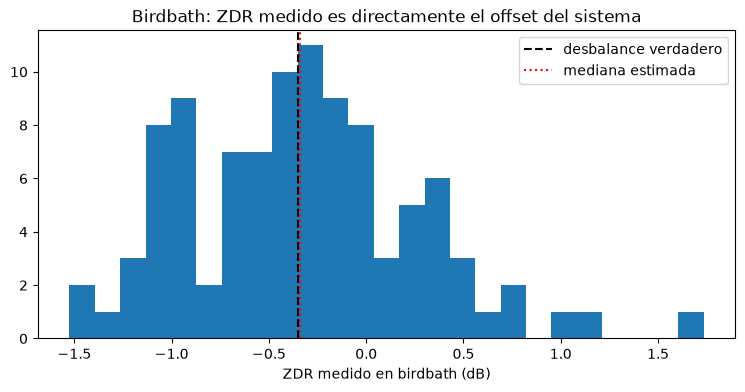

In [4]:
GAIN_IMBALANCE_BIRDBATH = -0.35
N_GATES_BIRDBATH = 100
BIRDBATH_TOLERANCE_DB = 0.1

zdr_birdbath = []
for _ in range(N_GATES_BIRDBATH):
    z = measure_zdr(POWER_H, 0.0, SIGMA_V, WAVELENGTH_M, PRT_S, M, 0.0, RHO_HV,
                     GAIN_IMBALANCE_BIRDBATH, NOISE_FLOOR, rng)
    if not np.isnan(z):
        zdr_birdbath.append(z)

offset_hat = np.median(zdr_birdbath)
print(f"desbalance inyectado={GAIN_IMBALANCE_BIRDBATH} dB  "
      f"estimado (mediana de {len(zdr_birdbath)} celdas)={offset_hat:.4f} dB")

fig, ax = plt.subplots()
ax.hist(zdr_birdbath, bins=25)
ax.axvline(GAIN_IMBALANCE_BIRDBATH, color="black", linestyle="--", label="desbalance verdadero")
ax.axvline(offset_hat, color="red", linestyle=":", label="mediana estimada")
ax.set_xlabel("ZDR medido en birdbath (dB)"); ax.legend()
ax.set_title("Birdbath: ZDR medido es directamente el offset del sistema")
plt.show()

checks.append((f"el procedimiento de birdbath recupera el desbalance inyectado dentro de {BIRDBATH_TOLERANCE_DB} dB",
               abs(offset_hat - GAIN_IMBALANCE_BIRDBATH) < BIRDBATH_TOLERANCE_DB))

## Prueba 3 — ΦDP de sistema: separar el offset de la fase de propagación

Perfil con fase de sistema fija más una fase de propagación que empieza a
crecer más allá de cierto rango (antes de eso, KDP≈0: aire despejado antes
de entrar en la precipitación). La estimación —mediana de las primeras
celdas, antes de que la propagación acumule nada— debe recuperar sólo la
parte de sistema, no una mezcla con la tendencia creciente.

ΦDP de sistema inyectado=15.0°  estimado (mediana de las primeras 20 celdas)=16.147°


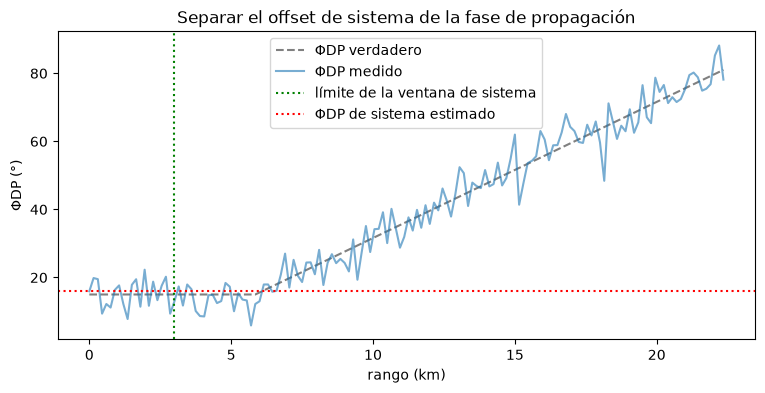

In [5]:
PHIDP_SYSTEM_TRUE = 15.0
N_GATES_PHIDP = 150
GATE_SPACING_KM = 0.150
K0 = 2.0
PROP_START_IDX = 40
FIRST_GATES = 20
PHIDP_TOLERANCE_DEG = 2.0

kdp_profile = np.where(np.arange(N_GATES_PHIDP) < PROP_START_IDX, 0.0, K0)
phidp_true_profile = PHIDP_SYSTEM_TRUE + 2.0 * np.cumsum(kdp_profile) * GATE_SPACING_KM

phidp_measured = np.array([
    measure_phidp(POWER_H, 5.0, SIGMA_V, WAVELENGTH_M, PRT_S, M, RHO_HV, phidp_true_profile[i], NOISE_FLOOR, rng)
    for i in range(N_GATES_PHIDP)
])
phidp_system_hat = np.median(phidp_measured[:FIRST_GATES])
print(f"ΦDP de sistema inyectado={PHIDP_SYSTEM_TRUE}°  "
      f"estimado (mediana de las primeras {FIRST_GATES} celdas)={phidp_system_hat:.3f}°")

fig, ax = plt.subplots()
r_km = np.arange(N_GATES_PHIDP) * GATE_SPACING_KM
ax.plot(r_km, phidp_true_profile, "--", color="gray", label="ΦDP verdadero")
ax.plot(r_km, phidp_measured, alpha=0.6, label="ΦDP medido")
ax.axvline(r_km[FIRST_GATES], color="green", linestyle=":", label="límite de la ventana de sistema")
ax.axhline(phidp_system_hat, color="red", linestyle=":", label="ΦDP de sistema estimado")
ax.set_xlabel("rango (km)"); ax.set_ylabel("ΦDP (°)"); ax.legend()
ax.set_title("Separar el offset de sistema de la fase de propagación")
plt.show()

checks.append((f"ΦDP de sistema recuperado dentro de {PHIDP_TOLERANCE_DEG}° del inyectado",
               abs(phidp_system_hat - PHIDP_SYSTEM_TRUE) < PHIDP_TOLERANCE_DEG))

## Fuera de alcance, declarado

- **Los tres métodos de determinación del offset de ZDR como campañas de
  operador** (inyección de señal en banco, birdbath real, comparación con
  llovizna/Bragg): la página los describe como procedimientos de campo, no
  algoritmos con verdad-terreno sintética propia más allá de lo que la
  Prueba 2 ya cubre (la simetría del birdbath es la única de las tres que
  se puede simular sin modelar hardware de banco que ninguna página
  especifica).
- **Aislamiento de polarización cruzada**: ya tiene su propio tratamiento
  numérico en el oráculo de `polarimetria-covarianzas.md` (la prueba de
  saturación de LDR); esta página sólo añade que el valor entra como límite
  de validez configurado, no como corrección — una regla de bookkeeping, no
  una cantidad nueva.
- **Interacción magnetrón/AFC con el offset de ZDR**: la página describe una
  correlación operativa a vigilar (revisar el offset con más frecuencia
  cuando el AFC se mueve), no un algoritmo con entrada/salida numérica
  propia.

In [6]:
all_ok = True
for name, ok in checks:
    print(f"[{'OK' if ok else 'FALLO'}] {name}")
    all_ok = all_ok and ok

assert all_ok, "el oráculo de calibración polarimétrica no pasa todas las comprobaciones — ver tabla arriba"
print("\nTodas las comprobaciones dentro de tolerancia.")

[OK] aplicar el offset conocido recupera ZDR dentro de 0.1 dB
[OK] el procedimiento de birdbath recupera el desbalance inyectado dentro de 0.1 dB
[OK] ΦDP de sistema recuperado dentro de 2.0° del inyectado

Todas las comprobaciones dentro de tolerancia.
